# Ordenar em Joules — caderno de análise

Memorial de cálculo do relatório em [`relatorio/`](../relatorio/). Cada número,
tabela e figura publicada sai de uma célula deste notebook.

**O experimento.** Doze programas de ordenação — seis em Go, seis em Rust —
medidos com `perf stat -a -e power/energy-pkg/` em duas máquinas separadas por
cinco anos de arquitetura Intel. Dez repetições por célula.

| Arquivo | Máquina | Execuções |
|:--|:--|--:|
| `medicoes_garbriel.csv` | Dell Inspiron 15 3511 · i5-1135G7 (Tiger Lake, 2020) | 360 |
| `medicoes_heitor2.csv` | HP · i5-5200U (Broadwell, 2015) | 720 |

`medicoes_heitor2.csv` substitui o `medicoes_heitor.csv` original: é uma
re-execução completa da bateria no HP, agora incluindo `insert_v2.go`, que
faltava. O arquivo antigo permanece no repositório apenas como histórico.

**Recorte: n ≥ 10 000.** Toda comparação deste notebook usa apenas as listas de
10 000 elementos em diante, por duas razões: o Dell só foi medido a partir desse
tamanho, e abaixo dele o contador RAPL não tem resolução para enxergar a
diferença (seção 3). Com o corte, o desenho fica **balanceado**: 12 programas ×
3 tamanhos × 10 repetições em **cada** máquina, 720 execuções no total.

As 360 execuções menores do HP continuam nos CSV e aparecem uma única vez neste
notebook — na seção 3, como a evidência que justifica o corte. Elas não entram em
nenhuma comparação.

**Ambiente.** `pandas`, `numpy`, `matplotlib`, `seaborn`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# funciona rodando da raiz do repositorio ou de dentro de analise/
AQUI = os.path.abspath("analise" if os.path.isdir("analise") else ".")
sys.path.insert(0, AQUI)

import dados, estatistica as est, graficos

dados.aplica_estilo()
sns.set_theme(style="whitegrid", rc=plt.rcParams)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

df = dados.carrega()              # so a faixa comparavel: n >= 10 000
df_todo = dados.carrega(minimo=0)  # inclui as execucoes pequenas do HP

tamanhos = lambda d: ", ".join(f"{v:,}".replace(",", " ") for v in sorted(d["n"].unique()))
print(f"comparacoes : {len(df)} execucoes  | n = {tamanhos(df)}")
print(f"dados brutos: {len(df_todo)} execucoes | n = {tamanhos(df_todo)}")
df.head()

comparacoes : 720 execucoes  | n = 10 000, 50 000, 100 000
dados brutos: 1080 execucoes | n = 10, 100, 1 000, 10 000, 50 000, 100 000


,maquina,familia,ling,algoritmo,linguagem,variante,n,execucao,energia_j,duracao_s,potencia_w,energia_cores_j,energia_ram_j,energia_por_elemento_uj,implementacao
0,Dell,Bubble ingênuo,Go,bolha,go,v1,10000,1,1.21,0.111786,10.8243,<NA>,<NA>,121.0,Bubble ingênuo · Go
1,Dell,Bubble ingênuo,Go,bolha,go,v1,10000,2,0.96,0.078501,12.2292,<NA>,<NA>,96.0,Bubble ingênuo · Go
2,Dell,Bubble ingênuo,Go,bolha,go,v1,10000,3,1.2,0.096928,12.3803,<NA>,<NA>,120.0,Bubble ingênuo · Go
3,Dell,Bubble ingênuo,Go,bolha,go,v1,10000,4,1.0,0.079039,12.6521,<NA>,<NA>,100.0,Bubble ingênuo · Go
4,Dell,Bubble ingênuo,Go,bolha,go,v1,10000,5,1.57,0.130216,12.0569,<NA>,<NA>,157.0,Bubble ingênuo · Go


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   maquina                  720 non-null    category
 1   familia                  720 non-null    category
 2   ling                     720 non-null    category
 3   algoritmo                720 non-null    object  
 4   linguagem                720 non-null    object  
 5   variante                 720 non-null    object  
 6   n                        720 non-null    Int64   
 7   execucao                 720 non-null    Int64   
 8   energia_j                720 non-null    Float64 
 9   duracao_s                720 non-null    Float64 
 10  potencia_w               720 non-null    Float64 
 11  energia_cores_j          360 non-null    Float64 
 12  energia_ram_j            360 non-null    Float64 
 13  energia_por_elemento_uj  720 non-null    Float64 
 14  implementacao        

---
## 1. Inventário

Depois do corte o desenho é uma grade **balanceada**: 12 programas × 3 tamanhos ×
10 repetições, igual nas duas máquinas. Antes de qualquer média, vale confirmar
que ela está mesmo completa e que nenhuma execução voltou sem energia ou sem
duração.

In [3]:
inventario = (df.pivot_table(index=["maquina", "familia", "ling"], columns="n",
                             values="execucao", aggfunc="count", observed=True)
                .fillna(0).astype(int))
inventario

n                                        10000   50000   100000
maquina familia                    ling                        
Dell    Bubble ingênuo             Go        10      10      10
                                   Rust      10      10      10
        Bubble otimizado           Go        10      10      10
                                   Rust      10      10      10
        Insertion por troca        Go        10      10      10
                                   Rust      10      10      10
        Insertion por deslocamento Go        10      10      10
                                   Rust      10      10      10
        Selection O(n²)            Go        10      10      10
                                   Rust      10      10      10
        Heapsort                   Go        10      10      10
                                   Rust      10      10      10
HP      Bubble ingênuo             Go        10      10      10
                                   Rust      10      10      10
        Bubble otimizado           Go        10      10      10
                                   Rust      10      10      10
        Insertion por troca        Go        10      10      10
                                   Rust      10      10      10
        Insertion por deslocamento Go        10      10      10
                                   Rust      10      10      10
        Selection O(n²)            Go        10      10      10
                                   Rust      10      10      10
        Heapsort                   Go        10      10      10
                                   Rust      10      10      10

In [4]:
resumo_maquina = df.groupby("maquina", observed=True).agg(
    execucoes=("energia_j", "size"),
    programas=("implementacao", "nunique"),
    tamanhos=("n", "nunique"),
    energia_total_j=("energia_j", "sum"),
    tempo_total_min=("duracao_s", lambda s: s.sum() / 60),
    sem_energia=("energia_j", lambda s: s.isna().sum()),
    sem_duracao=("duracao_s", lambda s: s.isna().sum()),
)
display(resumo_maquina.round(1))

total = df["energia_j"].sum()
print(f"\nenergia gasta no experimento inteiro: {total:,.0f} J = {total/3600:.2f} Wh"
      .replace(",", " "))

,execucoes,programas,tamanhos,energia_total_j,tempo_total_min,sem_energia,sem_duracao
maquina,,,,,,,
Dell,360,12,3,9369.7,12.2,0,0
HP,360,12,3,7198.8,20.2,0,0



energia gasta no experimento inteiro: 16 568 J = 4.60 Wh


---
## 2. O descasamento `v1`/`v2` — a correção que muda o resultado

Os programas são nomeados `v1` e `v2` em cada linguagem, e o pareamento óbvio é
comparar `v1` com `v1`. **Lendo os fontes, isso está errado para `selection`:**

- `go/go_algs/selection_v1.go` monta um *heap* com `container/heap` → é
  **heapsort**, Θ(n log n);
- `rust/rust_algs/selection_sort_v1.rs` é a **seleção clássica do mínimo**, Θ(n²);
- as versões `v2` invertem os papéis.

A célula abaixo mostra o número que o pareamento ingênuo produziria. Ele é real e
reprodutível — e não diz nada sobre linguagens, porque está medindo uma diferença
de complexidade assintótica.

In [5]:
ingenuo = (df[(df["algoritmo"] == "selection") & (df["n"] == dados.N_REF)]
           .pivot_table(index=["maquina", "variante"], columns="ling",
                        values="energia_j", aggfunc="mean", observed=True))
ingenuo["razao"] = ingenuo.max(axis=1) / ingenuo.min(axis=1)
ingenuo["a_favor_de"] = np.where(ingenuo["Go"] < ingenuo["Rust"], "Go", "Rust")
display(ingenuo.round(3))
print("^ heapsort contra selecao quadratica. Nao e um resultado sobre linguagens.")

ling                  Go    Rust    razao a_favor_de
maquina variante                                    
Dell    v1         0.445  32.299   72.582         Go
        v2        38.796   0.215  180.447       Rust
HP      v1         0.338  28.759   85.086         Go
        v2        36.374    0.16  227.338       Rust

^ heapsort contra selecao quadratica. Nao e um resultado sobre linguagens.


In [6]:
mapa = (pd.DataFrame([(a, l, v, f) for (a, l, v), f in dados.FAMILIAS.items()],
                     columns=["algoritmo", "linguagem", "variante", "familia"])
          .pivot_table(index="familia", columns="linguagem", values="variante",
                       aggfunc="first", observed=True)
          .reindex(dados.ORDEM_FAMILIAS))
mapa.columns = ["variante em Go", "variante em Rust"]
mapa

,variante em Go,variante em Rust
familia,,
Bubble ingênuo,v1,v1
Bubble otimizado,v2,v2
Insertion por troca,v1,v1
Insertion por deslocamento,v2,v2
Selection O(n²),v2,v1
Heapsort,v1,v2


Em `Selection O(n²)` e `Heapsort` as variantes ficam cruzadas — é exatamente esse
o descasamento. A coluna `familia` do DataFrame já aplica o pareamento correto, e
todo o resto do notebook usa ela.

Uma ressalva que o relatório repete: **`Bubble otimizado` não é uma comparação
limpa de linguagem.** As duas otimizações são diferentes — em Rust o limite do laço
externo recua até a última troca; em Go, além da *flag* de troca, o maior elemento
é transferido para um vetor de saída com `slices.Insert` na posição 0, o que custa
O(n) por remoção. Essa família mede "linguagem + decisão de implementação".

---
## 3. Por que o corte em n = 10 000

Esta seção é a única que olha para as execuções pequenas do HP. Elas não são um
resultado: são a medida do **instrumento**, e é o que justifica descartar tudo
abaixo de 10 000 elementos das comparações.

In [7]:
piso = est.piso(df_todo, "HP", n=10)   # precisa dos dados sem o corte
heapsort_rust_hp = df.query("maquina=='HP' and familia=='Heapsort' and ling=='Rust' and n==100000")["energia_j"].mean()
bubble_go_hp = df.query("maquina=='HP' and familia=='Bubble ingênuo' and ling=='Go' and n==100000")["energia_j"].mean()

print("PISO DO INSTRUMENTO (HP, n = 10)")
print(f"   {piso['energia_j']:.4f} J em {piso['duracao_s']*1000:.2f} ms  ->  {piso['potencia_w']:.1f} W")
print(f"   = {100*piso['energia_j']/heapsort_rust_hp:5.1f}% do heapsort em Rust (n = 100 000)")
print(f"   = {100*piso['energia_j']/bubble_go_hp:8.4f}% do bubble ingenuo em Go (n = 100 000)")
print("\n-> as cifras de heapsort sao um LIMITE SUPERIOR do custo do algoritmo.")

passos = np.sort(df_todo.query("maquina=='HP' and n<=1000")["energia_j"].unique())
print(f"\nRESOLUCAO: valores distintos medidos no HP em n <= 1000: {passos[:8]} ...")
print(f"   menor passo entre valores: {np.diff(passos).min():.3f} J")

PISO DO INSTRUMENTO (HP, n = 10)
   0.0186 J em 2.85 ms  ->  6.5 W
   =  11.6% do heapsort em Rust (n = 100 000)
   =   0.0158% do bubble ingenuo em Go (n = 100 000)

-> as cifras de heapsort sao um LIMITE SUPERIOR do custo do algoritmo.

RESOLUCAO: valores distintos medidos no HP em n <= 1000: [0.01 0.02 0.03 0.04] ...
   menor passo entre valores: 0.010 J


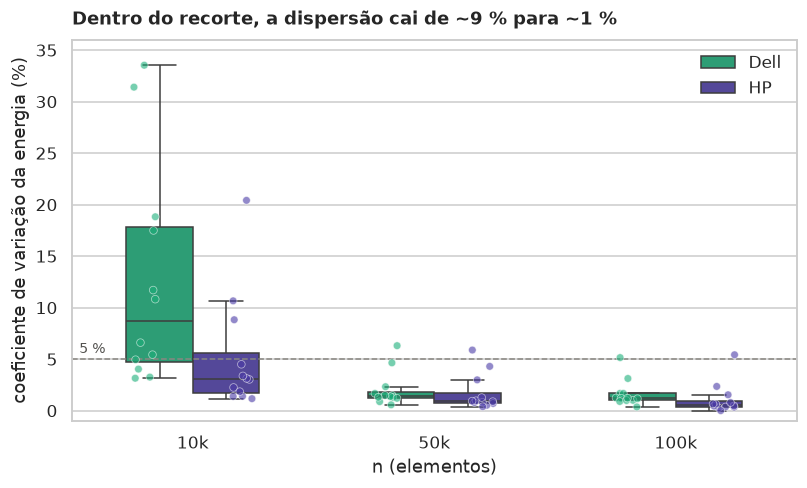

median        max      
maquina   Dell   HP  Dell    HP
n                              
10000      8.7  3.1  33.5  20.4
50000      1.4  0.9   6.3   5.9
100000     1.2  0.5   5.1   5.4

1 celula(s) com CV exatamente ZERO: as 10 leituras cairam todas no
mesmo passo de 0,01 J do contador. Nao e estabilidade — e falta de resolucao.


,maquina,familia,ling,n,energia_j_media
71,HP,Heapsort,Rust,100000,0.16


In [8]:
# quanto as 10 repeticoes de uma mesma celula variam entre si
cv = est.resumo(df)
rotulo_n = lambda v: f"{v//1000}k" if v >= 1000 else str(v)
cv["n_rotulo"] = cv["n"].map(rotulo_n)
ordem = [rotulo_n(v) for v in sorted(cv["n"].unique())]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
paleta = {"Dell": dados.COR["Dell"], "HP": dados.COR["HP"]}
sns.boxplot(data=cv, x="n_rotulo", y="energia_j_cv", hue="maquina", order=ordem,
            ax=ax, palette=paleta, width=0.55, fliersize=0, linewidth=1)
sns.stripplot(data=cv, x="n_rotulo", y="energia_j_cv", hue="maquina", order=ordem,
              ax=ax, palette=paleta, dodge=True, size=5, alpha=0.6,
              edgecolor="#fcfcfb", linewidth=0.5, legend=False)
ax.axhline(5, color=dados.SUAVE, ls="--", lw=1)
ax.annotate("5 %", (0.01, 5), xycoords=("axes fraction", "data"), xytext=(0, 4),
            textcoords="offset points", color=dados.TINTA2, fontsize=9)
ax.set_ylim(-1, 36)
ax.set_xlabel("n (elementos)")
ax.set_ylabel("coeficiente de variação da energia (%)")
ax.set_title("Dentro do recorte, a dispersão cai de ~9 % para ~1 %")
ax.legend(title="", loc="upper right")
plt.show()

display(cv.pivot_table(index="n", columns="maquina", values="energia_j_cv",
                       aggfunc=["median", "max"], observed=True).round(1))

zeradas = cv[cv["energia_j_cv"] < 1e-9]
if len(zeradas):
    print(f"{len(zeradas)} celula(s) com CV exatamente ZERO: as 10 leituras cairam todas no")
    print("mesmo passo de 0,01 J do contador. Nao e estabilidade — e falta de resolucao.")
    display(zeradas[["maquina", "familia", "ling", "n", "energia_j_media"]])

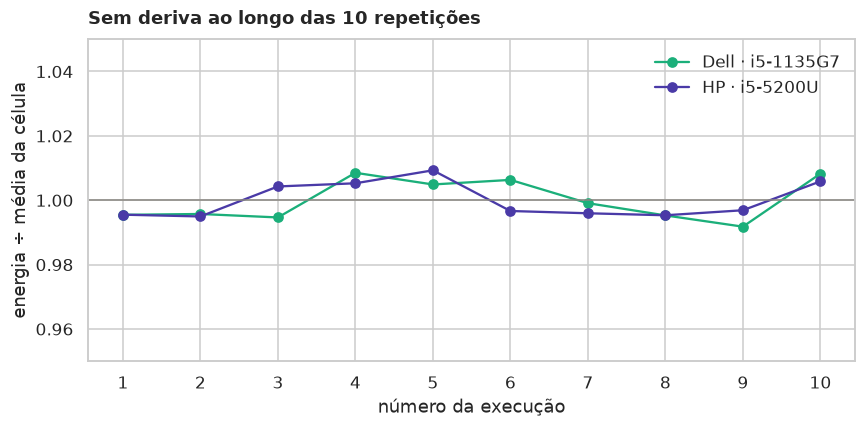

razao entre a 1a execucao e a media das nove seguintes:
maquina
Dell    0.995
HP      0.995

-> a ausencia de uma fase explicita de aquecimento nao introduziu vies detectavel.


In [9]:
# a maquina esquentou ao longo das 10 repeticoes?
deriva = est.deriva(df)
fig, ax = plt.subplots(figsize=(9, 3.8))
for maq in dados.ORDEM_MAQUINAS:
    ax.plot(deriva.index, deriva[maq], marker="o", color=dados.COR[maq],
            label=dados.MAQUINA_CURTA[maq])
ax.axhline(1, color=dados.SUAVE, lw=1)
ax.set_ylim(0.95, 1.05)
ax.set_xticks(range(1, 11))
ax.set_xlabel("número da execução")
ax.set_ylabel("energia ÷ média da célula")
ax.set_title("Sem deriva ao longo das 10 repetições")
ax.legend()
plt.show()

print("razao entre a 1a execucao e a media das nove seguintes:")
print((deriva.iloc[0] / deriva.iloc[1:].mean()).round(3).to_string())
print("\n-> a ausencia de uma fase explicita de aquecimento nao introduziu vies detectavel.")

In [10]:
# o efeito do piso sobre a inclinacao: o mesmo ajuste, com e sem os tamanhos pequenos
com_pequenos = est.expoentes(df_todo[df_todo["maquina"] == "HP"],
                             tamanhos=(1_000, 10_000, 50_000, 100_000), metrica="energia_j")
so_grandes = est.expoentes(df[df["maquina"] == "HP"], metrica="energia_j")
comparacao = pd.concat({"com n = 1 000": com_pequenos["HP"], "só n >= 10 000": so_grandes["HP"]},
                       axis=1).round(2)
display(comparacao)
print("-> incluir n = 1 000 derruba os expoentes de ~2,0 para ~1,8: as celulas pequenas")
print("   medem o piso, nao o algoritmo, e achatam a curva. Dai o corte.")

com n = 1 000       só n >= 10 000      
ling                                  Go  Rust             Go  Rust
familia                                                            
Bubble ingênuo                      1.79  1.81           2.01  1.98
Bubble otimizado                    1.79  1.79           2.02  2.01
Insertion por troca                 1.55  1.38           1.95  1.93
Insertion por deslocamento          1.38  1.29           1.95  1.91
Selection O(n²)                     1.59  1.58           2.02  1.96
Heapsort                            0.60  0.46           0.88  0.82

-> incluir n = 1 000 derruba os expoentes de ~2,0 para ~1,8: as celulas pequenas
   medem o piso, nao o algoritmo, e achatam a curva. Dai o corte.


A partir daqui, **tudo usa apenas n ≥ 10 000**.

---
## 4. Rust × Go, dentro de cada família

Para cada família, a razão entre a média de Go e a média de Rust: acima de 1,00
significa que Go gastou mais, ou seja, **Rust venceu**.

O intervalo de confiança de 95% vem de *bootstrap* (20 000 reamostragens com
reposição das 10 execuções de cada lado); o *d* de Cohen mede o tamanho do efeito
em desvios-padrão.

In [11]:
razoes_energia = est.razoes(df, "energia_j")
razoes_energia[["maquina", "familia", "go", "rust", "razao", "ic_baixo", "ic_alto",
                "d_cohen", "vencedor", "fator", "significativo"]].round(3)

,maquina,familia,go,rust,razao,ic_baixo,ic_alto,d_cohen,vencedor,fator,significativo
0,Dell,Bubble ingênuo,189.121,126.858,1.491,1.472,1.510,24.949,Rust,1.491,True
1,Dell,Bubble otimizado,171.855,129.005,1.332,1.315,1.347,19.244,Rust,1.332,True
2,Dell,Insertion por troca,34.918,10.649,3.279,3.252,3.302,80.837,Rust,3.279,True
3,Dell,Insertion por deslocamento,9.569,11.584,0.826,0.819,0.833,-20.044,Go,1.211,True
4,Dell,Selection O(n²),38.796,32.299,1.201,1.188,1.214,15.393,Rust,1.201,True
5,Dell,Heapsort,0.445,0.215,2.070,1.995,2.147,13.624,Rust,2.070,True
6,HP,Bubble ingênuo,117.931,123.009,0.959,0.943,0.969,-2.469,Go,1.043,True
7,HP,Bubble otimizado,120.465,87.376,1.379,1.374,1.383,83.230,Rust,1.379,True
8,HP,Insertion por troca,26.130,11.645,2.244,2.233,2.254,144.904,Rust,2.244,True
9,HP,Insertion por deslocamento,11.730,7.428,1.579,1.564,1.597,32.559,Rust,1.579,True


In [12]:
razoes_tempo = est.razoes(df, "duracao_s")
razoes_tempo[["maquina", "familia", "go", "rust", "razao", "ic_baixo", "ic_alto",
              "d_cohen", "vencedor", "fator", "significativo"]].round(3)

,maquina,familia,go,rust,razao,ic_baixo,ic_alto,d_cohen,vencedor,fator,significativo
0,Dell,Bubble ingênuo,14.525,10.356,1.403,1.399,1.406,115.583,Rust,1.403,True
1,Dell,Bubble otimizado,12.296,10.462,1.175,1.172,1.179,42.874,Rust,1.175,True
2,Dell,Insertion por troca,3.097,0.866,3.576,3.574,3.578,2072.436,Rust,3.576,True
3,Dell,Insertion por deslocamento,0.705,0.981,0.719,0.718,0.719,-314.670,Go,1.391,True
4,Dell,Selection O(n²),3.241,2.408,1.346,1.345,1.347,524.138,Rust,1.346,True
5,Dell,Heapsort,0.033,0.017,1.907,1.820,1.987,12.394,Rust,1.907,True
6,HP,Bubble ingênuo,19.799,20.830,0.950,0.946,0.953,-11.223,Go,1.052,True
7,HP,Bubble otimizado,19.467,15.124,1.287,1.286,1.288,419.243,Rust,1.287,True
8,HP,Insertion por troca,4.640,1.980,2.343,2.341,2.345,838.919,Rust,2.343,True
9,HP,Insertion por deslocamento,1.809,1.242,1.456,1.451,1.461,89.266,Rust,1.456,True


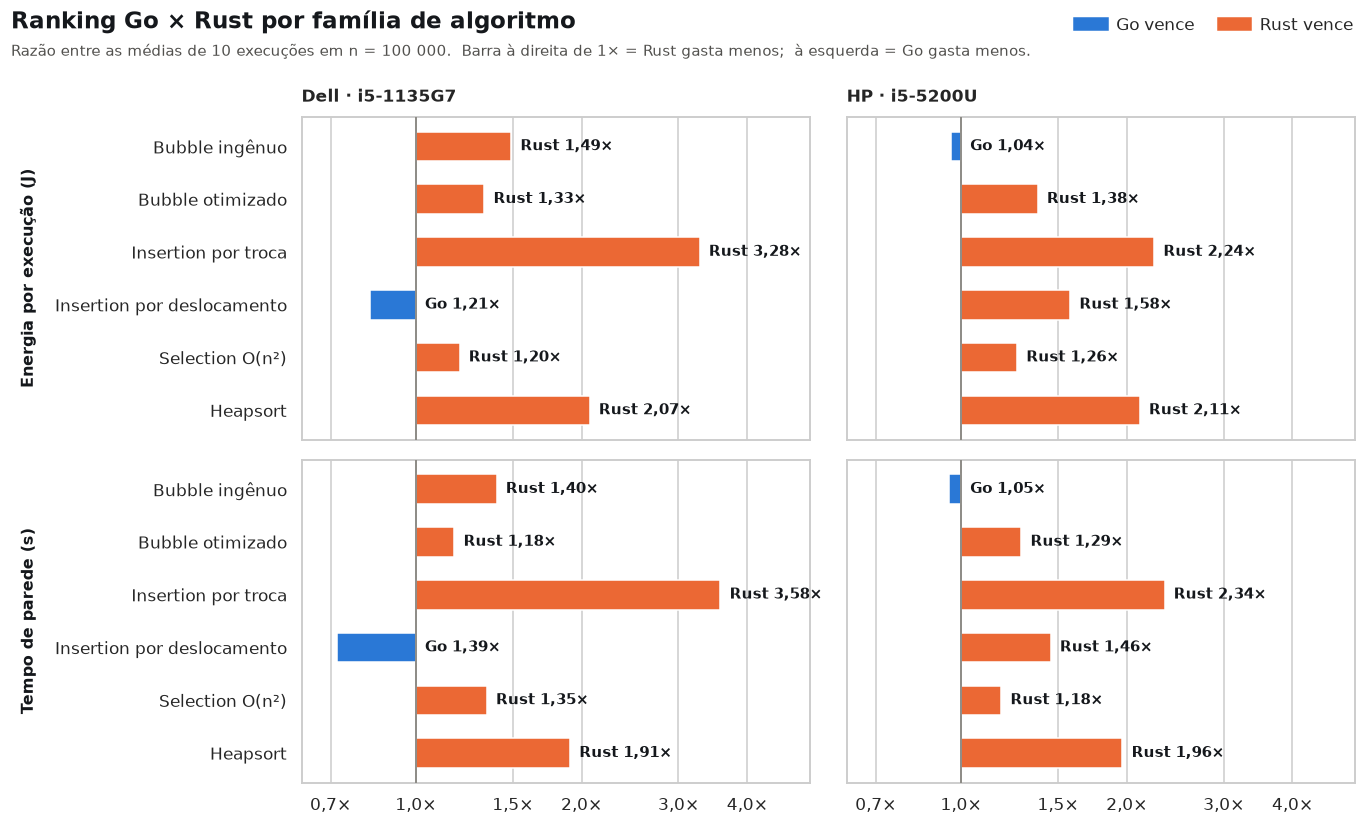

In [13]:
fig = graficos.ranking_linguagens(df)
plt.show()

In [14]:
placar = razoes_energia.pivot_table(index="familia", columns="maquina",
                                    values="vencedor", aggfunc="first", observed=True)
display(placar)

print("Rust vence:")
for maq in dados.ORDEM_MAQUINAS:
    n_rust = (placar[maq] == "Rust").sum()
    perde = list(placar.index[placar[maq] == "Go"])
    print(f"   {dados.MAQUINA_CURTA[maq]:20} {n_rust} de {len(placar)}   (Go vence em: {perde})")

inversoes = placar[placar["Dell"] != placar["HP"]]
print(f"\nINVERSOES DE SINAL entre as maquinas: {len(inversoes)}")
display(inversoes)

maquina,Dell,HP
familia,,
Bubble ingênuo,Rust,Go
Bubble otimizado,Rust,Rust
Insertion por troca,Rust,Rust
Insertion por deslocamento,Go,Rust
Selection O(n²),Rust,Rust
Heapsort,Rust,Rust


Rust vence:
   Dell · i5-1135G7     5 de 6   (Go vence em: ['Insertion por deslocamento'])
   HP · i5-5200U        5 de 6   (Go vence em: ['Bubble ingênuo'])

INVERSOES DE SINAL entre as maquinas: 2


maquina,Dell,HP
familia,,
Bubble ingênuo,Rust,Go
Insertion por deslocamento,Go,Rust


---
## 5. O algoritmo domina a linguagem

A diferença entre linguagens só faz sentido medida contra a diferença entre
algoritmos.

In [15]:
medias = (df[df["n"] == dados.N_REF]
          .groupby(["maquina", "implementacao"], observed=True)["energia_j"].mean())

for maq in dados.ORDEM_MAQUINAS:
    s = medias.loc[maq].sort_values()
    alcance_alg = s.iloc[-1] / s.iloc[0]
    alcance_ling = razoes_energia.loc[razoes_energia["maquina"] == maq, "fator"].max()
    print(f"{dados.MAQUINA_CURTA[maq]}")
    print(f"   melhor: {s.index[0]:35} {s.iloc[0]:9.3f} J")
    print(f"   pior:   {s.index[-1]:35} {s.iloc[-1]:9.3f} J")
    print(f"   alcance do ALGORITMO:  {alcance_alg:7.0f}x")
    print(f"   alcance da LINGUAGEM:  {alcance_ling:7.2f}x")
    print(f"   -> o algoritmo tem {alcance_alg/alcance_ling:.0f}x mais alcance\n")

Dell · i5-1135G7
   melhor: Heapsort · Rust                         0.215 J
   pior:   Bubble ingênuo · Go                   189.121 J
   alcance do ALGORITMO:      880x
   alcance da LINGUAGEM:     3.28x
   -> o algoritmo tem 268x mais alcance

HP · i5-5200U
   melhor: Heapsort · Rust                         0.160 J
   pior:   Bubble ingênuo · Rust                 123.009 J
   alcance do ALGORITMO:      769x
   alcance da LINGUAGEM:     2.24x
   -> o algoritmo tem 343x mais alcance



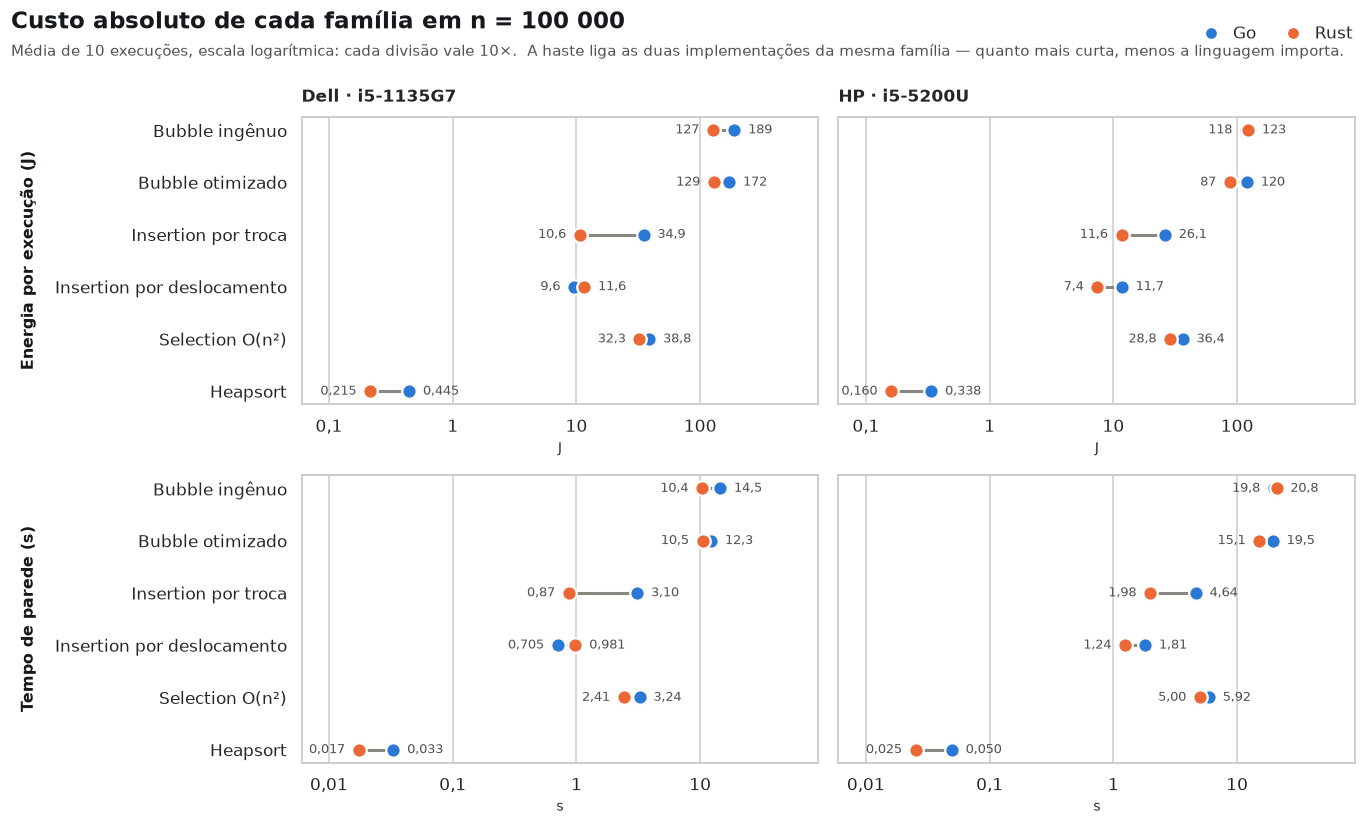

In [16]:
fig = graficos.custo_absoluto(df)
plt.show()

---
## 6. Escalabilidade: a complexidade aparece nos dados?

A inclinação da reta log–log contra *n* deve valer 2 para os algoritmos
quadráticos. Com três tamanhos o ajuste é curto, mas suficiente para separar o
quadrático do n log n. O heapsort deveria ficar perto de 1 — e não fica, pelo
motivo diagnosticado na seção 3.

In [17]:
# expoente da ENERGIA contra n -- e a metrica que a figura 3 desenha
expoentes_energia = est.expoentes(df, metrica="energia_j")
display(expoentes_energia.round(2))

quad = expoentes_energia.drop(index="Heapsort")
print(f"quadraticos no HP:   {quad['HP'].min().min():.2f} a {quad['HP'].max().max():.2f}")
print(f"quadraticos no Dell: {quad['Dell'].min().min():.2f} a {quad['Dell'].max().max():.2f}")
print(f"heapsort:            {expoentes_energia.loc['Heapsort'].min():.2f} a "
      f"{expoentes_energia.loc['Heapsort'].max():.2f}")

maquina                     Dell          HP      
ling                          Go  Rust    Go  Rust
familia                                           
Bubble ingênuo              2.22  2.40  2.01  1.98
Bubble otimizado            2.33  2.46  2.02  2.01
Insertion por troca         1.95  1.87  1.95  1.93
Insertion por deslocamento  1.85  1.90  1.95  1.91
Selection O(n²)             1.96  1.96  2.02  1.96
Heapsort                    0.81  0.70  0.88  0.82

quadraticos no HP:   1.91 a 2.02
quadraticos no Dell: 1.85 a 2.46
heapsort:            0.70 a 0.88


In [18]:
# o mesmo ajuste sobre o tempo, para conferir que a conclusao nao depende da metrica
est.expoentes(df, metrica="duracao_s").round(2)

maquina                     Dell          HP      
ling                          Go  Rust    Go  Rust
familia                                           
Bubble ingênuo              2.19  2.39  1.99  1.99
Bubble otimizado            2.32  2.45  2.00  1.99
Insertion por troca         1.92  1.84  1.95  1.91
Insertion por deslocamento  1.73  1.81  1.92  1.89
Selection O(n²)             1.94  1.92  2.00  1.96
Heapsort                    0.74  0.60  0.84  0.71

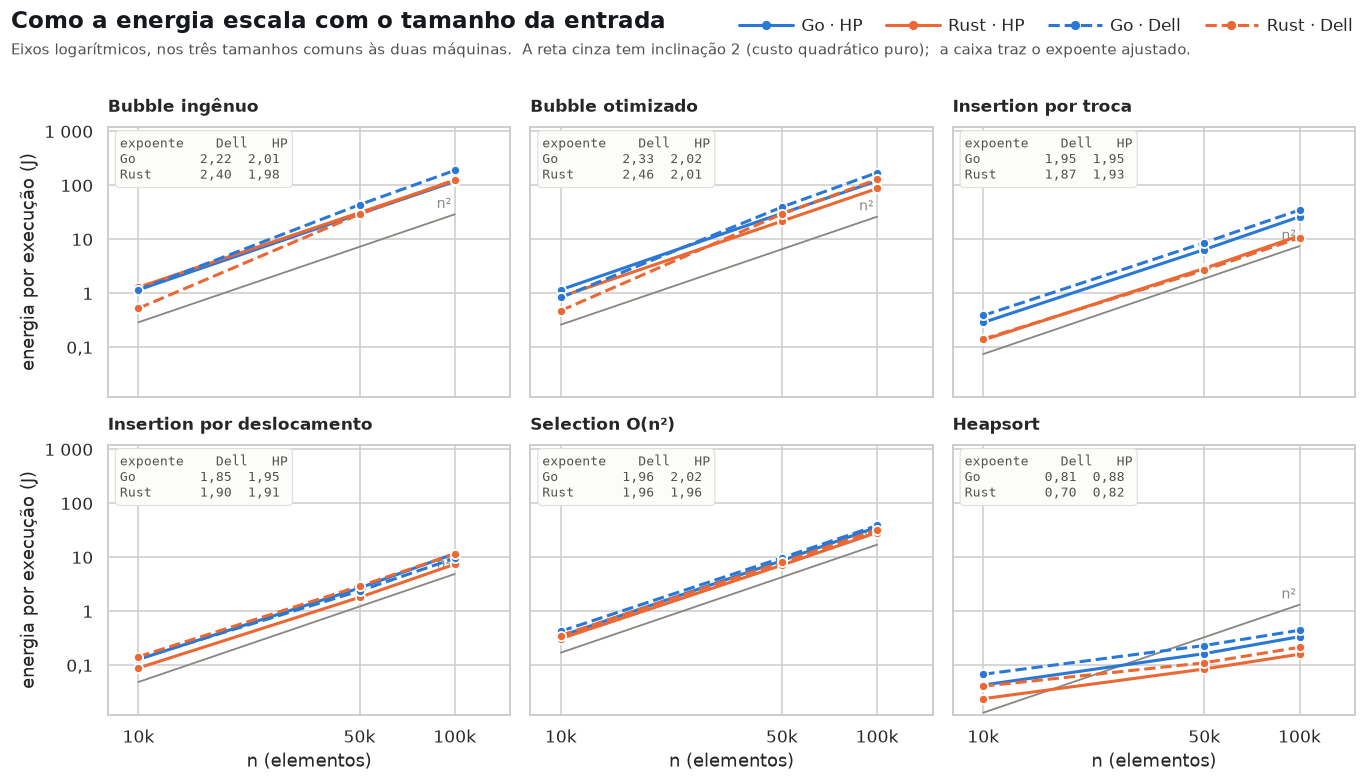

In [19]:
fig = graficos.escala(df)
plt.show()

---
## 7. O ranking depende da máquina

Esta é a segunda pergunta de pesquisa. As duas máquinas rodaram exatamente os
mesmos 12 programas sobre exatamente as mesmas listas. Se o ranking fosse uma
propriedade das linguagens e dos algoritmos, seria o mesmo nas duas.

In [20]:
rk = est.ranking(df)
display(rk[["implementacao", "posicao_Dell", "energia_j_Dell",
            "posicao_HP", "energia_j_HP", "delta"]].round(3))
print(f"{(rk['delta'] != 0).sum()} das {len(rk)} posicoes mudam entre as maquinas.")

,implementacao,posicao_Dell,energia_j_Dell,posicao_HP,energia_j_HP,delta
0,Heapsort · Rust,1.0,0.215,1.0,0.16,0.0
1,Heapsort · Go,2.0,0.445,2.0,0.338,0.0
2,Insertion por deslocamento · Go,3.0,9.569,5.0,11.73,2.0
3,Insertion por troca · Rust,4.0,10.649,4.0,11.645,0.0
4,Insertion por deslocamento · Rust,5.0,11.584,3.0,7.428,-2.0
5,Selection O(n²) · Rust,6.0,32.299,7.0,28.759,1.0
6,Insertion por troca · Go,7.0,34.918,6.0,26.13,-1.0
7,Selection O(n²) · Go,8.0,38.796,8.0,36.374,0.0
8,Bubble ingênuo · Rust,9.0,126.858,12.0,123.009,3.0
9,Bubble otimizado · Rust,10.0,129.005,9.0,87.376,-1.0


7 das 12 posicoes mudam entre as maquinas.


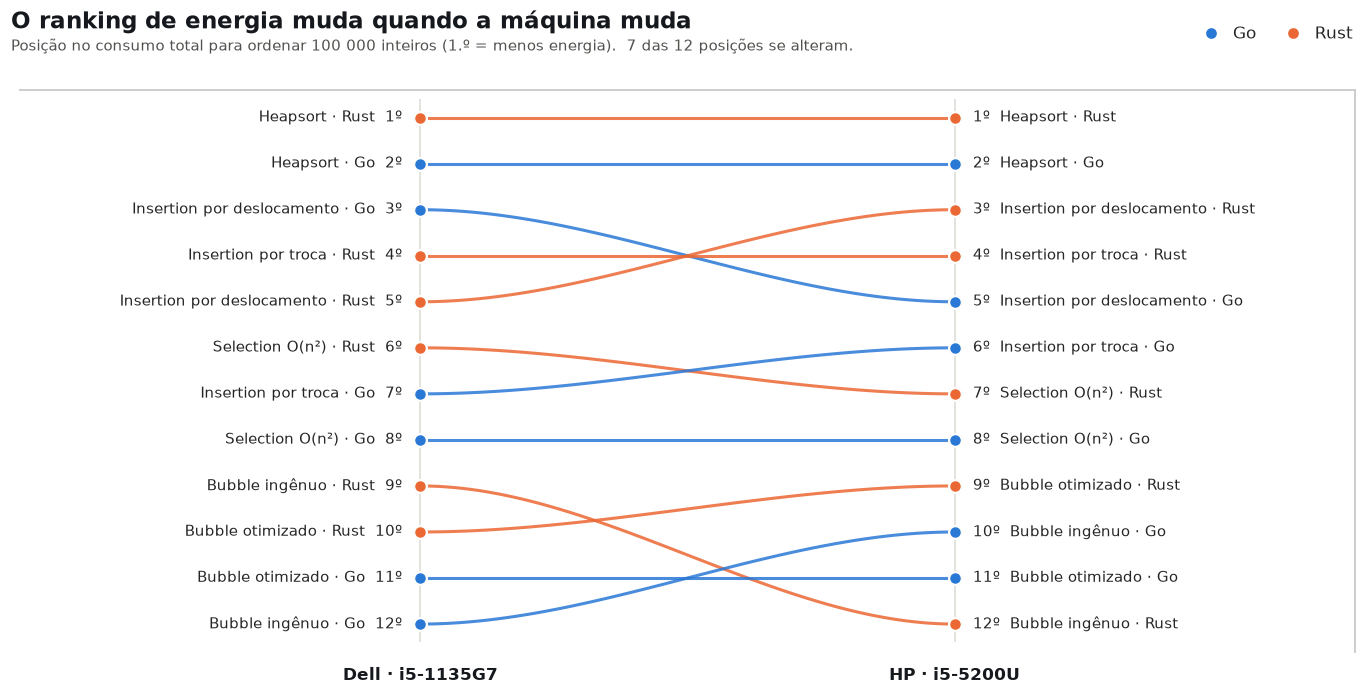

In [21]:
fig = graficos.mudanca_de_ranking(df)
plt.show()

---
## 8. Energia é tempo × potência da plataforma

`perf stat -a` mede o pacote inteiro durante a janela de execução. Sem uma linha de
base ociosa, o que se mede é **energia-até-concluir da máquina**, não a energia
marginal do algoritmo. A potência quase não varia, então E ≈ P·t e o ranking de
energia quase replica o de tempo.

In [22]:
potencia = (df[df["n"] >= 10_000]
            .pivot_table(index="maquina", columns="ling", values="potencia_w",
                         aggfunc="mean", observed=True))
potencia["Go acima de Rust"] = (100 * (potencia["Go"] / potencia["Rust"] - 1)).round(1).astype(str) + " %"
display(potencia.round(2))
print("-> Go sustenta alguns pontos percentuais a mais, compativel com o runtime")
print("   manter threads e coletor de lixo ativos ao lado do laco de ordenacao.")

ling,Go,Rust,Go acima de Rust
maquina,,,
Dell,12.56,12.1,3.8 %
HP,6.06,5.8,4.4 %


-> Go sustenta alguns pontos percentuais a mais, compativel com o runtime
   manter threads e coletor de lixo ativos ao lado do laco de ordenacao.


In [23]:
# mais rapido nao e mais verde: Dell contra HP na mesma tarefa
comp = (df[df["n"] == dados.N_REF]
        .pivot_table(index="implementacao", columns="maquina",
                     values=["energia_j", "duracao_s"], aggfunc="mean", observed=True))
comp["speedup_dell"] = comp[("duracao_s", "HP")] / comp[("duracao_s", "Dell")]
comp["energia_dell_sobre_hp"] = comp[("energia_j", "Dell")] / comp[("energia_j", "HP")]
comp["dell_gasta_mais"] = comp["energia_dell_sobre_hp"] > 1
display(comp[["speedup_dell", "energia_dell_sobre_hp", "dell_gasta_mais"]].round(2)
            .sort_values("energia_dell_sobre_hp", ascending=False))
print(f"O Dell e mais rapido em todas as {len(comp)} implementacoes "
      f"({comp['speedup_dell'].min():.2f}x a {comp['speedup_dell'].max():.2f}x),")
print(f"mas gasta MAIS energia em {int(comp['dell_gasta_mais'].sum())} delas.")

,speedup_dell,energia_dell_sobre_hp,dell_gasta_mais
maquina,,,
implementacao,,,
Bubble ingênuo · Go,1.36,1.6,True
Insertion por deslocamento · Rust,1.27,1.56,True
Bubble otimizado · Rust,1.45,1.48,True
Bubble otimizado · Go,1.58,1.43,True
Insertion por troca · Go,1.5,1.34,True
Heapsort · Rust,1.45,1.34,True
Heapsort · Go,1.49,1.32,True
Selection O(n²) · Rust,2.08,1.12,True


O Dell e mais rapido em todas as 12 implementacoes (1.27x a 2.57x),
mas gasta MAIS energia em 10 delas.


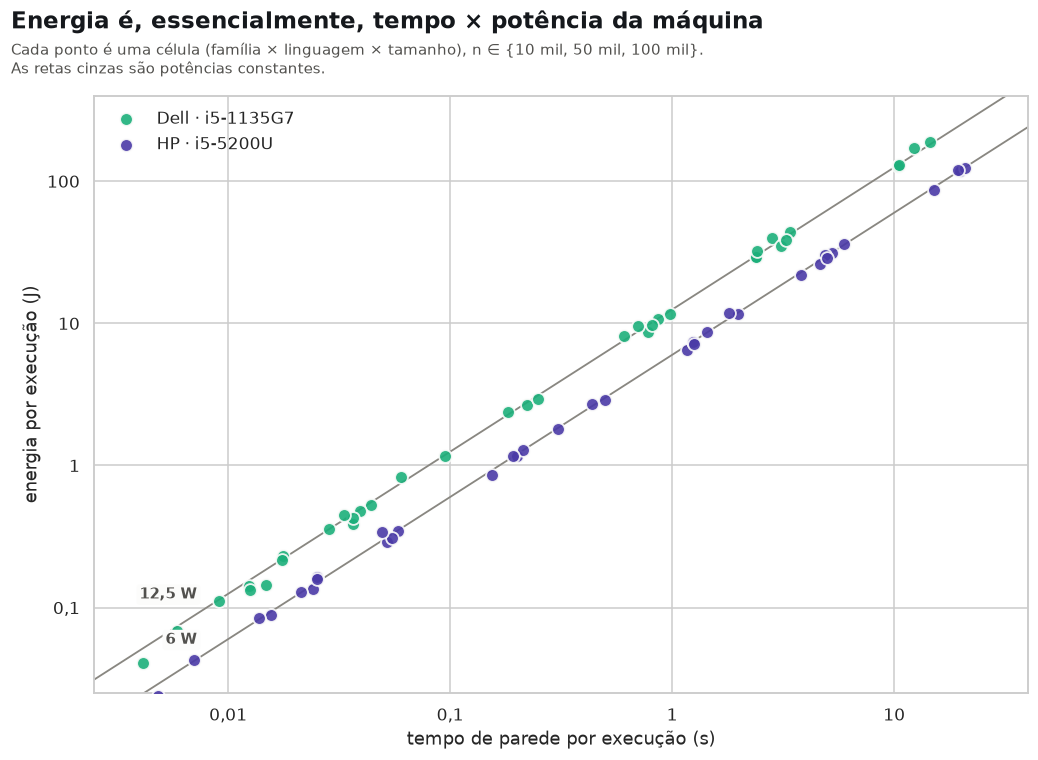

In [24]:
fig = graficos.energia_contra_tempo(df)
plt.show()

---
## 9. Tamanho de efeito prático

Quase todas as diferenças são estatisticamente sólidas (vários *d* acima de 20).
Isso diz pouco sobre se elas **importam**. A tradução abaixo é a de um serviço que
ordene um milhão de listas de 100 000 inteiros por dia.

In [25]:
ORDENACOES_DIA = 1_000_000
kwh = lambda joules: joules * ORDENACOES_DIA / 3.6e6

linhas = []
for maq in dados.ORDEM_MAQUINAS:
    s = medias.loc[maq].sort_values()
    heap = s[["Heapsort · Go", "Heapsort · Rust"]]
    ganho_alg = s.iloc[-1] - s.iloc[0]
    ganho_ling = heap["Heapsort · Go"] - heap["Heapsort · Rust"]
    linhas += [
        {"maquina": maq, "decisão": f"algoritmo ({s.index[-1]} → {s.index[0]})",
         "ganho_J": ganho_alg, "ganho_kWh_dia": kwh(ganho_alg)},
        {"maquina": maq, "decisão": "linguagem (Heapsort · Go → Heapsort · Rust)",
         "ganho_J": ganho_ling, "ganho_kWh_dia": kwh(ganho_ling)},
    ]
pratico = pd.DataFrame(linhas)
display(pratico.round(3))

for maq in dados.ORDEM_MAQUINAS:
    p = pratico[pratico["maquina"] == maq]
    print(f"{dados.MAQUINA_CURTA[maq]}: a escolha do algoritmo tem "
          f"{p['ganho_J'].iloc[0]/p['ganho_J'].iloc[1]:.0f}x a alavancagem da linguagem")

,maquina,decisão,ganho_J,ganho_kWh_dia
0,Dell,algoritmo (Bubble ingênuo · Go → Heapsort · Rust),188.906,52.474
1,Dell,linguagem (Heapsort · Go → Heapsort · Rust),0.230,0.064
2,HP,algoritmo (Bubble ingênuo · Rust → Heapsort · ...,122.849,34.125
3,HP,linguagem (Heapsort · Go → Heapsort · Rust),0.178,0.049


Dell · i5-1135G7: a escolha do algoritmo tem 821x a alavancagem da linguagem
HP · i5-5200U: a escolha do algoritmo tem 690x a alavancagem da linguagem


---
## 10. Tabelas completas

In [26]:
def tabela_por_tamanho(n):
    t = est.resumo(df)
    t = t[t["n"] == n].set_index(["familia", "ling", "maquina"])
    t = t[["energia_j_media", "energia_j_dp", "duracao_s_media", "duracao_s_dp",
           "potencia_w_media"]]
    t["uJ_por_elemento"] = t["energia_j_media"] / n * 1e6
    return t.round(4)

tabela_por_tamanho(100_000)

energia_j_media  energia_j_dp  duracao_s_media  duracao_s_dp  potencia_w_media  \
familia                    ling maquina                                                                                   
Bubble ingênuo             Go   Dell             189.121        3.1617          14.5246        0.0486            13.021   
                           Rust Dell             126.858        1.5682          10.3561        0.0156           12.2497   
Bubble otimizado           Go   Dell             171.855        2.8724          12.2964        0.0546           13.9757   
                           Rust Dell             129.005        1.2908          10.4622         0.026           12.3306   
Insertion por troca        Go   Dell              34.918        0.4228           3.0967        0.0013            11.276   
                           Rust Dell              10.649        0.0383           0.8659        0.0007           12.2986   
Insertion por deslocamento Go   Dell               9.569        0.0851            0.705        0.0006           13.5732   
                           Rust Dell              11.584        0.1139           0.9809        0.0011           11.8102   
Selection O(n²)            Go   Dell              38.796        0.4503           3.2413        0.0021           11.9694   
                           Rust Dell              32.299        0.3918           2.4081        0.0007           13.4127   
Heapsort                   Go   Dell               0.445        0.0229           0.0332        0.0015           13.4557   
                           Rust Dell               0.215        0.0067           0.0174        0.0009           12.3764   
Bubble ingênuo             Go   HP               117.931        0.3234          19.7987        0.0115            5.9565   
                           Rust HP               123.009        2.8904          20.8301        0.1295            5.9047   
Bubble otimizado           Go   HP               120.465        0.4102          19.4667        0.0108            6.1883   
                           Rust HP                87.376        0.3845          15.1237        0.0099            5.7774   
Insertion por troca        Go   HP                 26.13        0.1202           4.6401         0.004            5.6313   
                           Rust HP                11.645        0.0745           1.9803         0.002            5.8804   
Insertion por deslocamento Go   HP                 11.73        0.1804           1.8085        0.0079            6.4858   
                           Rust HP                 7.428        0.0487           1.2425        0.0042            5.9783   
Selection O(n²)            Go   HP                36.374        0.1311           5.9206        0.0053            6.1436   
                           Rust HP                28.759        0.2256           5.0024         0.011             5.749   
Heapsort                   Go   HP                 0.338        0.0183           0.0496        0.0017            6.8166   
                           Rust HP                  0.16           0.0           0.0252        0.0003            6.3432   

                                         uJ_por_elemento  
familia                    ling maquina                   
Bubble ingênuo             Go   Dell             1891.21  
                           Rust Dell             1268.58  
Bubble otimizado           Go   Dell             1718.55  
                           Rust Dell             1290.05  
Insertion por troca        Go   Dell              349.18  
                           Rust Dell              106.49  
Insertion por deslocamento Go   Dell               95.69  
                           Rust Dell              115.84  
Selection O(n²)            Go   Dell              387.96  
                           Rust Dell              322.99  
Heapsort                   Go   Dell                4.45  
                           Rust Dell                2.15  
Bubble ingênuo  

In [27]:
tabela_por_tamanho(50_000)

energia_j_media  energia_j_dp  duracao_s_media  duracao_s_dp  potencia_w_media  \
familia                    ling maquina                                                                                   
Bubble ingênuo             Go   Dell              43.765        1.0162           3.4007        0.0128           12.8696   
                           Rust Dell              29.259        0.2555           2.3853        0.0025           12.2663   
Bubble otimizado           Go   Dell              39.627        0.5867           2.8271        0.0051           14.0168   
                           Rust Dell              29.487          0.38           2.3939        0.0078           12.3176   
Insertion por troca        Go   Dell               8.665        0.1184           0.7794        0.0009           11.1178   
                           Rust Dell               2.677        0.0447           0.2208        0.0005           12.1266   
Insertion por deslocamento Go   Dell               2.383        0.0352           0.1817        0.0011           13.1169   
                           Rust Dell               2.914         0.035           0.2498        0.0004           11.6672   
Selection O(n²)            Go   Dell               9.753         0.055           0.8135        0.0011           11.9892   
                           Rust Dell               8.084         0.105           0.6078        0.0004           13.3007   
Heapsort                   Go   Dell               0.232        0.0108           0.0177        0.0014             13.15   
                           Rust Dell               0.111         0.007           0.0091        0.0001           12.2395   
Bubble ingênuo             Go   HP                29.577        0.2323           4.9668        0.0074            5.9549   
                           Rust HP                31.239         1.342           5.2446        0.0655            5.9543   
Bubble otimizado           Go   HP                30.245        0.2113           4.8785        0.0077            6.1996   
                           Rust HP                21.712        0.2092            3.795        0.0119            5.7211   
Insertion por troca        Go   HP                 6.454        0.0335            1.168        0.0007            5.5255   
                           Rust HP                  2.89        0.0253           0.5005        0.0009            5.7738   
Insertion por deslocamento Go   HP                 2.697        0.0219           0.4368         0.002            6.1743   
                           Rust HP                 1.811         0.023           0.3067        0.0009            5.9051   
Selection O(n²)            Go   HP                 8.664        0.0332           1.4373        0.0017             6.028   
                           Rust HP                 7.154        0.0661           1.2558        0.0011            5.6968   
Heapsort                   Go   HP                 0.164        0.0049           0.0252        0.0002             6.502   
                           Rust HP                 0.085         0.005           0.0138        0.0002            6.1778   

                                         uJ_por_elemento  
familia                    ling maquina                   
Bubble ingênuo             Go   Dell               875.3  
                           Rust Dell              585.18  
Bubble otimizado           Go   Dell              792.54  
                           Rust Dell              589.74  
Insertion por troca        Go   Dell               173.3  
                           Rust Dell               53.54  
Insertion por deslocamento Go   Dell               47.66  
                           Rust Dell               58.28  
Selection O(n²)            Go   Dell              195.06  
                           Rust Dell              161.68  
Heapsort                   Go   Dell                4.64  
                           Rust Dell                2.22  
Bubble ingênuo  

In [28]:
tabela_por_tamanho(10_000)

energia_j_media  energia_j_dp  duracao_s_media  duracao_s_dp  potencia_w_media  \
familia                    ling maquina                                                                                   
Bubble ingênuo             Go   Dell                1.16        0.2183           0.0953        0.0196           12.2285   
                           Rust Dell               0.528        0.0166           0.0439        0.0015           12.0388   
Bubble otimizado           Go   Dell               0.836        0.0454           0.0604         0.007           13.9517   
                           Rust Dell               0.477        0.0155           0.0392        0.0008           12.1775   
Insertion por troca        Go   Dell               0.388        0.0256           0.0365        0.0056           10.7319   
                           Rust Dell               0.142        0.0154           0.0124        0.0011           11.4807   
Insertion por deslocamento Go   Dell               0.133        0.0233           0.0125         0.006           11.3831   
                           Rust Dell               0.144        0.0169           0.0148        0.0043           10.0269   
Selection O(n²)            Go   Dell               0.426        0.0211           0.0367        0.0008           11.6108   
                           Rust Dell               0.355        0.0143           0.0286        0.0009           12.4117   
Heapsort                   Go   Dell               0.068        0.0214           0.0059        0.0038           12.6565   
                           Rust Dell               0.041        0.0137           0.0041         0.003           11.1992   
Bubble ingênuo             Go   HP                 1.158         0.016           0.2006        0.0004            5.7728   
                           Rust HP                 1.293        0.0581           0.2136        0.0031            6.0503   
Bubble otimizado           Go   HP                 1.164        0.0162           0.1928        0.0022            6.0387   
                           Rust HP                 0.863          0.01           0.1541        0.0003            5.6015   
Insertion por troca        Go   HP                 0.288        0.0087           0.0518        0.0005            5.5604   
                           Rust HP                 0.136         0.012           0.0241        0.0004            5.6421   
Insertion por deslocamento Go   HP                 0.128         0.004           0.0213        0.0002              6.02   
                           Rust HP                 0.089         0.003           0.0156        0.0001            5.6863   
Selection O(n²)            Go   HP                 0.347        0.0064           0.0583        0.0004            5.9512   
                           Rust HP                 0.311         0.007           0.0546        0.0003            5.6913   
Heapsort                   Go   HP                 0.043        0.0046            0.007        0.0001            6.1101   
                           Rust HP                 0.024        0.0049           0.0048        0.0001            4.9546   

                                         uJ_por_elemento  
familia                    ling maquina                   
Bubble ingênuo             Go   Dell               116.0  
                           Rust Dell                52.8  
Bubble otimizado           Go   Dell                83.6  
                           Rust Dell                47.7  
Insertion por troca        Go   Dell                38.8  
                           Rust Dell                14.2  
Insertion por deslocamento Go   Dell                13.3  
                           Rust Dell                14.4  
Selection O(n²)            Go   Dell                42.6  
                           Rust Dell                35.5  
Heapsort                   Go   Dell                 6.8  
                           Rust Dell                 4.1  
Bubble ingênuo  

In [29]:
# o HP registrou os dominios RAPL separados; vale ver como a energia se reparte
rapl = (df[(df["maquina"] == "HP") & (df["n"] == dados.N_REF)]
        .groupby("implementacao", observed=True)[["energia_j", "energia_cores_j", "energia_ram_j"]]
        .mean())
rapl["cores_%"] = 100 * rapl["energia_cores_j"] / rapl["energia_j"]
rapl["dram_%"] = 100 * rapl["energia_ram_j"] / rapl["energia_j"]
rapl["resto_%"] = 100 - rapl["cores_%"] - rapl["dram_%"]
display(rapl.round(2).sort_values("energia_j", ascending=False))
print("-> a reparticao e estavel (~72% cores, ~19% dram) em todas as implementacoes:")
print("   nenhuma delas e mais intensiva em memoria que as outras de forma relevante.")

,energia_j,energia_cores_j,energia_ram_j,cores_%,dram_%,resto_%
implementacao,,,,,,
Bubble ingênuo · Rust,123.01,88.41,22.58,71.87,18.36,9.77
Bubble otimizado · Go,120.46,88.15,20.79,73.18,17.26,9.56
Bubble ingênuo · Go,117.93,85.12,21.15,72.17,17.94,9.89
Bubble otimizado · Rust,87.38,61.95,16.14,70.9,18.47,10.63
Selection O(n²) · Go,36.37,26.61,6.32,73.15,17.39,9.46
Selection O(n²) · Rust,28.76,20.47,5.35,71.19,18.59,10.22
Insertion por troca · Go,26.13,18.29,4.96,70.0,18.99,11.02
Insertion por deslocamento · Go,11.73,8.8,1.94,75.02,16.58,8.4
Insertion por troca · Rust,11.64,8.39,2.12,72.03,18.2,9.77


-> a reparticao e estavel (~72% cores, ~19% dram) em todas as implementacoes:
   nenhuma delas e mais intensiva em memoria que as outras de forma relevante.


---
## 11. As figuras do relatório

As cinco figuras acima são as mesmas que o relatório publica. Os arquivos em
`relatorio/img/*.png`, porém, **não** são gravados por este notebook: quem os
produz é o script, sempre no mesmo backend, para que o resultado seja idêntico a
cada execução.

```bash
python3 analise/graficos.py
```

(O backend inline do Jupyter renderiza texto com métricas um pouco diferentes do
Agg, e `bbox_inches="tight"` recorta alguns pixels a mais ou a menos. Deixar um
único produtor dos arquivos evita que a figura publicada mude sozinha só porque
foi salva de um lugar diferente.)

---
## Ameaças à validade — o que este notebook **não** resolve

1. **Não há linha de base ociosa.** Nenhuma das duas máquinas mediu o consumo em
   repouso, então não é possível separar a energia do algoritmo da energia da
   máquina ligada enquanto ele roda. É a lacuna mais séria do conjunto.
2. **O piso do instrumento** contamina o heapsort (~12% do total em n = 100 000).
   Tudo abaixo de n = 10 000 já foi descartado por isso, mas o heapsort continua
   afetado mesmo dentro do recorte.
3. **A janela inclui E/S e *parsing*** — cada execução lê a lista do `stdin` e
   imprime a saída ordenada, e esse custo O(n) está dentro da medição.
4. **`Bubble otimizado` compara otimizações diferentes**, não linguagens (seção 2).
5. **Os ambientes não estão equiparados**: distribuição, kernel, *governor* e
   toolchain do Dell não foram registrados; a versão do Go no HP é desconhecida.
6. **Uma única entrada por tamanho** — tudo aqui vale para uma permutação aleatória
   fixa. Entradas já ordenadas mudariam as famílias com parada antecipada.
7. **Apenas três tamanhos.** O recorte em n ≥ 10 000 deixa três pontos para
   ajustar cada expoente — o bastante para distinguir Θ(n²) de Θ(n log n), pouco
   para estimar a constante com precisão.
8. **Duas máquinas não são uma amostra.** Mostramos que o ranking *pode* mudar com
   a plataforma; não estimamos com que frequência isso acontece.